In [16]:
from typing import TypedDict,List,Annotated
import operator
import os
from pydantic import BaseModel,Field
from langgraph.graph import StateGraph,START,END
from langgraph.types import Send
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage,HumanMessage

None


In [3]:
class Task(BaseModel):
    id:int
    title:str
    brief:str = Field(...,desription="What to cover")

C:\Users\ishita\AppData\Local\Temp\ipykernel_23596\2555383195.py:4: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'desription'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  brief:str = Field(...,desription="What to cover")


In [4]:
class Plan(BaseModel):
    blog_title:str
    tasks:List[Task]

In [19]:
class State(TypedDict):
    topic:str
    plan:Plan
    #reducer : results from workers get concatanated automatically
    sections:Annotated[List[str],operator.add]#will have output of each worker node
    final:str

In [39]:
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENROUTER_API_KEY")
os.environ["OPENAI_BASE_URL"] = "https://openrouter.ai/api/v1"

In [18]:
llm = ChatOpenAI(
    model=os.getenv("LLM_MODEL", "nvidia/nemotron-3-super-120b-a12b:free"),
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
)

In [ ]:
def orchestrator(state:State)->dict:
     plan=llm.with_structured_output(Plan, method="function_calling").invoke(
          [
               SystemMessage(
                    content=(
                         "Create a blog plan with 5-7 sections on the following topic."
                    )
               ),
               HumanMessage(content=f"Topic:{state['topic']}"),
          ]
          
     )
     return {"plan":plan}

In [ ]:
#deciding how many worker will be there
# this function checks how many tasks/sections are there in the plan object and creates as many workers
# triggers for every state a worker(using send api)
def fanout(state:State):
    return [Send("worker",{"task":task,"topic":state['topic'],"plan":state["plan"]})
            for task in state["plan"].tasks]


In [ ]:
# task a worker is supposed to do,every worker performs work related to its own section
def worker(payload:dict)->dict:

    task=payload["task"]
    topic=payload["topic"]
    plan=payload["plan"]

    blog_title=plan.blog_title

    section_md=llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section"),
            HumanMessage(
                content=(
                    f"Blog:{blog_title}\n"
                    f"Topic:{topic}\n"
                    f"Section:{task.title}\n"
                    f"Brief:{task.brief}\n\n"
                    "Return only the section content in Markdown."
            )),
        ]
    ).content.strip()

    return {"sections":[section_md]}

In [24]:
from pathlib import Path

def reducer(state:State) -> dict:

    title = state["plan"].blog_title
    body="\n\n".join(state["sections"]).strip()
    # state section is a list of strings one section above it a line change below it also line change another section

    final_md=f"#{title}\n\n{body}\n"

    # save to file
    filename = title.lower().replace(" ","_")+".md"
    output_path=Path(filename)
    output_path.write_text(final_md,encoding="utf-8")

    return {"final": final_md}

In [41]:
g=StateGraph(State)
g.add_node("orchestrator",orchestrator)
g.add_node("worker", worker)
g.add_node("reducer",reducer)

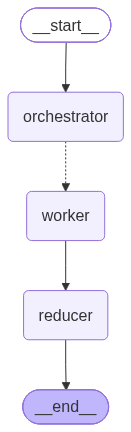

In [42]:
g.add_edge(START,"orchestrator")
g.add_conditional_edges("orchestrator",fanout,["worker"])
g.add_edge("worker","reducer")
g.add_edge("reducer",END)

app=g.compile()

app

In [43]:
out=app.invoke({"topic":"Write a blog on self attention"})

AuthenticationError: Error code: 401 - {'error': {'message': 'Missing Authentication header', 'code': 401}}

In [28]:
print(out['plan'])

NameError: name 'out' is not defined